In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import re
import string

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
!pip install wordcloud

from wordcloud import WordCloud

import nltk

In [3]:
!pip install nltk wordcloud

In [4]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\JASLEEN
[nltk_data]     KAUR\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
#Loading the Dataset
df = pd.read_csv("spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [8]:
#Data information

print("information:",df.info())
print()
print("Shape:")
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB
information: None

Shape:
Rows : 5572
Columns : 5


In [9]:
#Remove unnecesarry columns
#Most versions of spam.csv have extra unnamed columns.

df = df[['v1','v2']]

df.columns = ['Label','Message']

df.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
#Checking Null value
df.isnull().sum()

Label      0
Message    0
dtype: int64

In [11]:
#Checking duplicate values
print("Duplicate rows :", df.duplicated().sum())

Duplicate rows : 403


In [13]:
#Cleaning the data by removing duplicates
df.drop_duplicates(inplace=True)

df.reset_index(drop=True,inplace=True)

df.shape

(5169, 2)

In [19]:
#Class Distribution
df['Label'].value_counts()

Label
ham     4516
spam     653
Name: count, dtype: int64

In [17]:
#percentage distribution
percentage = df['Label'].value_counts(normalize=True)*100

print("Percentage:",percentage)

Percentage: Label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64


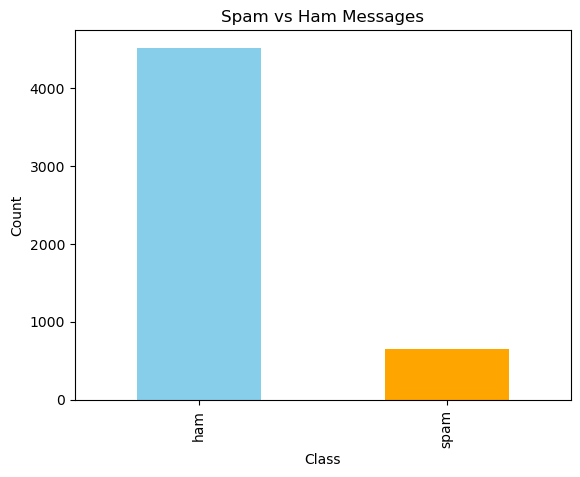

In [20]:
#Visual bar garph
df['Label'].value_counts().plot(
    kind='bar',
    color=['skyblue','orange']
)

plt.title("Spam vs Ham Messages")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [21]:
'''## Class Distribution

The dataset contains two classes:

• Ham – Legitimate messages

• Spam – Unwanted promotional or fraudulent messages

The class distribution is checked to understand whether the dataset is balanced or imbalanced before training machine learning models.'''

'## Class Distribution\n\nThe dataset contains two classes:\n\n• Ham – Legitimate messages\n\n• Spam – Unwanted promotional or fraudulent messages\n\nThe class distribution is checked to understand whether the dataset is balanced or imbalanced before training machine learning models.'

In [22]:
#Convert labels
df['Label'] = df['Label'].map({
    'ham':0,
    'spam':1
})

df.head()

,Label,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [23]:
#Stopwards
stop_words = set(stopwords.words('english'))

stemmer = PorterStemmer()

In [24]:
#Preprocessing func
def preprocess(text):

    text = text.lower()

    text = re.sub(r'http\S+',' ',text)

    text = re.sub(r'\d+',' ',text)

    text = text.translate(
        str.maketrans('','',string.punctuation)
    )

    words = text.split()

    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [25]:
#Apply preprocessing
df['Clean_Message'] = df['Message'].apply(preprocess)

df.head()

,Label,Message,Clean_Message
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,0,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


In [ ]:
## TF-IDF Vectorizer

TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numerical values that machine learning algorithms can understand.

- Term Frequency (TF) measures how often a word appears in a document.
- Inverse Document Frequency (IDF) reduces the importance of words that appear in many documents.

Words that are frequent in one message but rare across all messages receive higher weights.

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df["Clean_Message"])

y = df["Label"]

print(X.shape)

(5169, 3000)


In [29]:
#train and test splt
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4135, 3000)
(1034, 3000)


In [30]:
#multinominal naive bayes
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

In [31]:
#Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Accuracy :", accuracy_score(y_test, nb_pred))
print("Precision :", precision_score(y_test, nb_pred))
print("Recall :", recall_score(y_test, nb_pred))
print("F1 Score :", f1_score(y_test, nb_pred))

Accuracy : 0.9748549323017408
Precision : 1.0
Recall : 0.8206896551724138
F1 Score : 0.9015151515151515


In [32]:
#Classification report
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       889
           1       1.00      0.82      0.90       145

    accuracy                           0.97      1034
   macro avg       0.99      0.91      0.94      1034
weighted avg       0.98      0.97      0.97      1034



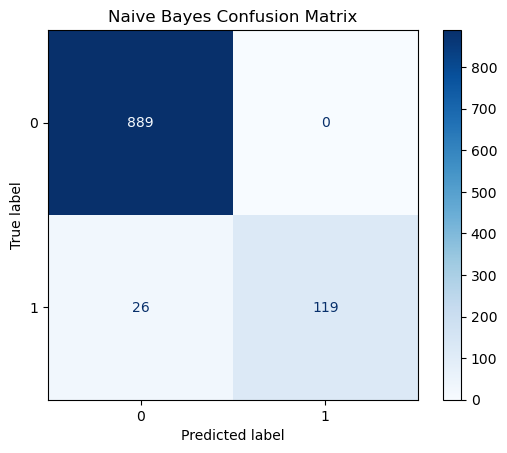

In [33]:
#Confusion Matrix
cm = confusion_matrix(y_test, nb_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Naive Bayes Confusion Matrix")

plt.show()

In [34]:
#Logistic  regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [35]:
#Evaluation
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision :", precision_score(y_test, lr_pred))
print("Recall :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

Accuracy : 0.9555125725338491
Precision : 0.9459459459459459
Recall : 0.7241379310344828
F1 Score : 0.8203125


In [36]:
#Classification report
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       889
           1       0.95      0.72      0.82       145

    accuracy                           0.96      1034
   macro avg       0.95      0.86      0.90      1034
weighted avg       0.96      0.96      0.95      1034



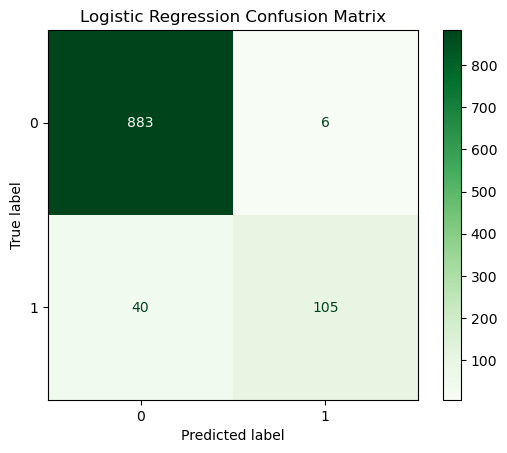

In [37]:
#Confusion Mtrix
cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Greens")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [38]:
#Compare models
results = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred)
    ],
    "Precision": [
        precision_score(y_test, nb_pred),
        precision_score(y_test, lr_pred)
    ],
    "Recall": [
        recall_score(y_test, nb_pred),
        recall_score(y_test, lr_pred)
    ],
    "F1 Score": [
        f1_score(y_test, nb_pred),
        f1_score(y_test, lr_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.974855,1.000000,0.820690,0.901515
1,Logistic Regression,0.955513,0.945946,0.724138,0.820312


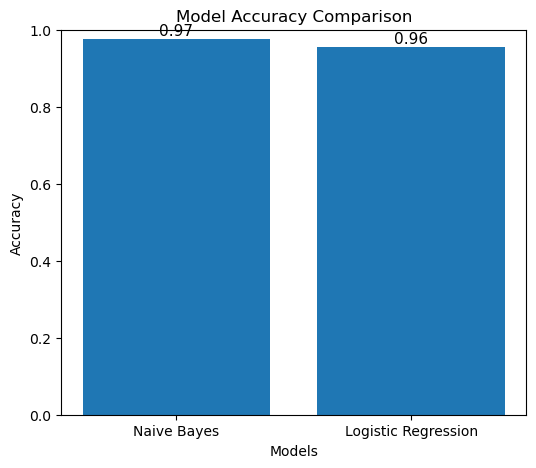

In [45]:
import matplotlib.pyplot as plt

models = ['Naive Bayes', 'Logistic Regression']

accuracies = [
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, lr_pred)
]

plt.figure(figsize=(6,5))
bars = plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

# Show accuracy values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.01,
             f'{height:.2f}',
             ha='center',
             fontsize=11)

plt.show()

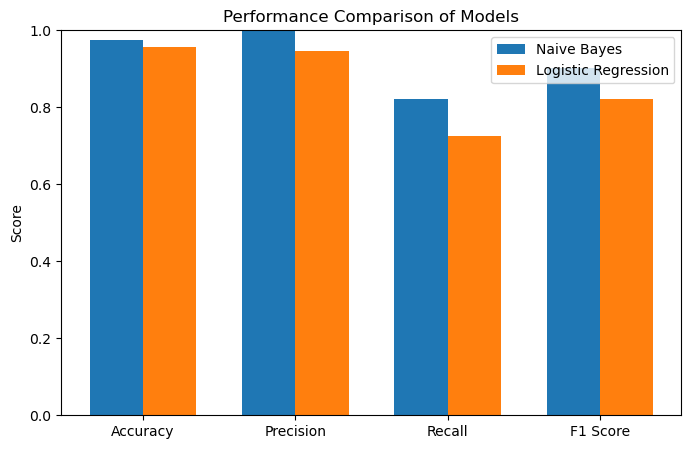

In [46]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

naive = [
    accuracy_score(y_test, nb_pred),
    precision_score(y_test, nb_pred),
    recall_score(y_test, nb_pred),
    f1_score(y_test, nb_pred)
]

logistic = [
    accuracy_score(y_test, lr_pred),
    precision_score(y_test, lr_pred),
    recall_score(y_test, lr_pred),
    f1_score(y_test, lr_pred)
]

import numpy as np

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, naive, width, label='Naive Bayes')
plt.bar(x + width/2, logistic, width, label='Logistic Regression')

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Performance Comparison of Models")
plt.ylim(0,1)
plt.legend()

plt.show()

In [48]:
#BEST MODEL
best_model = results.loc[results['Accuracy'].idxmax()]

print("Best Performing Model")
print("----------------------")
print("Model :", best_model['Model'])
print("Accuracy :", round(best_model['Accuracy']*100,2),"%")

Best Performing Model
----------------------
Model : Naive Bayes
Accuracy : 97.49 %


In [44]:
'''## Discussion: Why is Recall Particularly Important for Spam Detection?

Recall is the proportion of actual spam messages that are correctly identified by the model. In spam detection, achieving a high recall is crucial because failing to detect spam (false negatives) allows unwanted, fraudulent, or potentially harmful messages to reach the user's inbox.

For example, if a phishing email is incorrectly classified as a legitimate (ham) email, the user may open it and become a victim of fraud or malware. Therefore, a model with high recall minimizes the number of spam messages that are missed.

Although precision is also important to avoid classifying legitimate emails as spam, recall is often given higher priority in spam detection because missing dangerous spam messages can have more serious consequences than occasionally filtering a legitimate email.'''

"## Discussion: Why is Recall Particularly Important for Spam Detection?\n\nRecall is the proportion of actual spam messages that are correctly identified by the model. In spam detection, achieving a high recall is crucial because failing to detect spam (false negatives) allows unwanted, fraudulent, or potentially harmful messages to reach the user's inbox.\n\nFor example, if a phishing email is incorrectly classified as a legitimate (ham) email, the user may open it and become a victim of fraud or malware. Therefore, a model with high recall minimizes the number of spam messages that are missed.\n\nAlthough precision is also important to avoid classifying legitimate emails as spam, recall is often given higher priority in spam detection because missing dangerous spam messages can have more serious consequences than occasionally filtering a legitimate email."

In [39]:
!pip install wordcloud

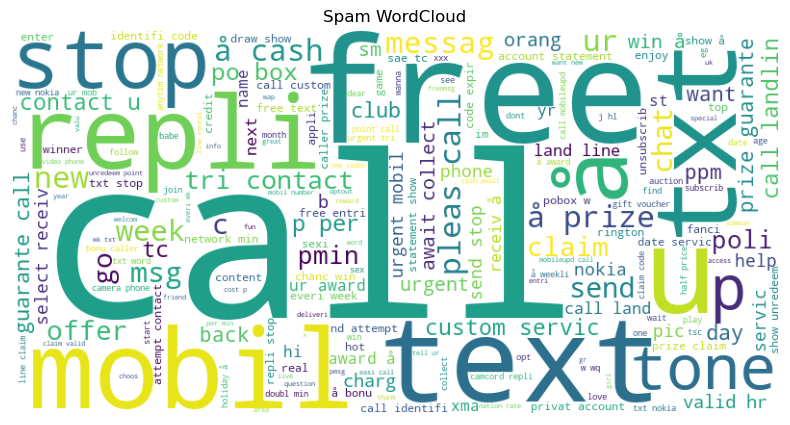

In [40]:
#WordCloud
from wordcloud import WordCloud

spam_text = " ".join(df[df["Label"] == 1]["Clean_Message"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Spam WordCloud")
plt.show()

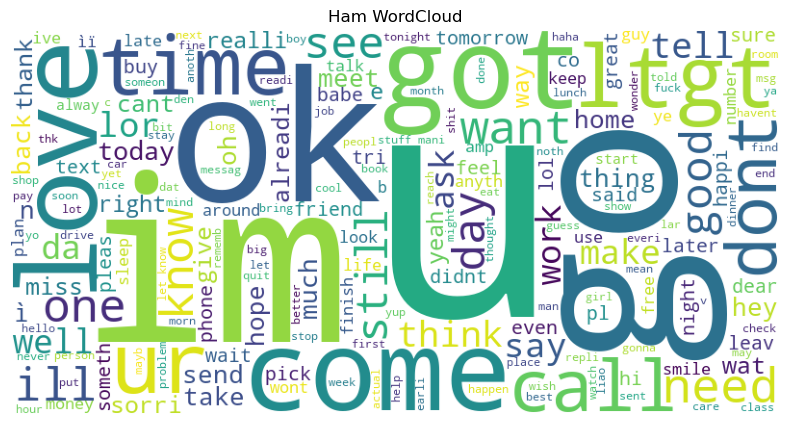

In [41]:
#Ham WordCloud
ham_text = " ".join(df[df["Label"] == 0]["Clean_Message"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(ham_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Ham WordCloud")
plt.show()

In [42]:
'''## Why is Recall Important in Spam Detection?

Recall measures the percentage of actual spam messages that are correctly identified by the model.

A high recall is important because missing spam emails means harmful or unwanted messages may reach users. Although precision is also important, maximizing recall helps reduce the chances of spam slipping into the inbox.'''

'## Why is Recall Important in Spam Detection?\n\nRecall measures the percentage of actual spam messages that are correctly identified by the model.\n\nA high recall is important because missing spam emails means harmful or unwanted messages may reach users. Although precision is also important, maximizing recall helps reduce the chances of spam slipping into the inbox.'

In [26]:
#Compare orginal vs clean
for i in range(5):
    print("Original :")
    print(df['Message'][i])

    print()

    print("Clean :")
    print(df['Clean_Message'][i])

    print("-"*80)

Original :
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Clean :
go jurong point crazi avail bugi n great world la e buffet cine got amor wat
--------------------------------------------------------------------------------
Original :
Ok lar... Joking wif u oni...

Clean :
ok lar joke wif u oni
--------------------------------------------------------------------------------
Original :
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

Clean :
free entri wkli comp win fa cup final tkt st may text fa receiv entri questionstd txt ratetc appli
--------------------------------------------------------------------------------
Original :
U dun say so early hor... U c already then say...

Clean :
u dun say earli hor u c alreadi say
--------------------------------------------------------------------------------
Original :
Nah

In [27]:
'''## Text Preprocessing

The preprocessing pipeline includes:

• Converting all text to lowercase.

• Removing punctuation.

• Removing numbers.

• Removing stopwords.

• Applying stemming using Porter Stemmer.

These steps reduce noise in the text and improve the quality of features extracted for machine learning.'''

'## Text Preprocessing\n\nThe preprocessing pipeline includes:\n\n• Converting all text to lowercase.\n\n• Removing punctuation.\n\n• Removing numbers.\n\n• Removing stopwords.\n\n• Applying stemming using Porter Stemmer.\n\nThese steps reduce noise in the text and improve the quality of features extracted for machine learning.'

In [ ]:
'''# Conclusion

This project successfully developed an Email Spam Detection system using Natural Language Processing (NLP) and Machine Learning.

The text messages were preprocessed by converting them to lowercase, removing punctuation, removing stopwords, and applying stemming. The cleaned text was transformed into numerical features using the TF-IDF Vectorizer.

Two machine learning models were trained and evaluated:

- Multinomial Naive Bayes
- Logistic Regression

Both models were evaluated using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

The comparison showed that **(write the model name with the higher accuracy)** achieved the best overall performance on this dataset.

The results demonstrate that machine learning combined with TF-IDF feature extraction can effectively distinguish spam messages from legitimate messages. Such systems help reduce unwanted emails, improve user experience, and protect users from phishing and fraudulent messages.'''